In [1]:
#is python selected as the kernel?
#have you closed the parameters excel sheet?

from config import *
from utils import *

import matplotlib.ticker as mticker
import matplotlib.pyplot as plt
import pandas as pd
import os
import numpy as np
import random

np.random.seed(42)
random.seed(42)

#if you get an error here you probably didn't close the parameters excel sheet

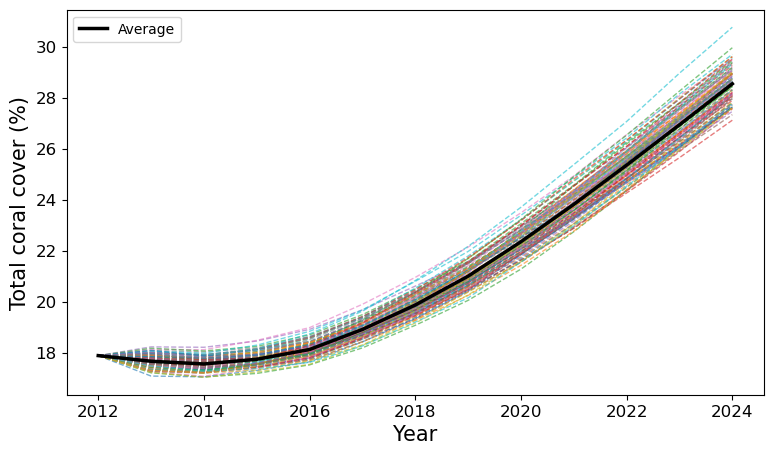


Extracting model data for plotting...
  ✓ Benthic data (13 rows)
  ✓ Coral cover df (13 rows)
  ✓ Rugosity (13 values)
  ✓ PSD data (39 rows, 20 bins)

✓ Extraction complete – ready for plotting!


In [2]:
# Run the model for n iterations (set in user_inputs), then extract all data
# needed by the plotting cells into global variables.

iteration_df, _ = run_multiple_model_iterations_total_cover(number_of_iterations)
plot_growth_rate_iterations(iteration_df)

# ── Extract data from opts into globals ──────────────────────────────────────
print("\nExtracting model data for plotting...")
n_years = year_end - year_start + 1

# Helper: safe column extraction
def _get(df, col, n):
    if col in df.columns:
        v = df[col].values
        return v[:n] if len(v) >= n else np.pad(v, (0, n - len(v)), constant_values=np.nan)
    return np.full(n, np.nan)

# Benthic data
if hasattr(opts, 'yearly_benthic_cover_df'):
    _df = opts.yearly_benthic_cover_df
    avail_m      = _get(_df, 'available_substrate (%)', n_years);  avail_s      = np.zeros(n_years)
    sed_m        = _get(_df, 'sediment (%)',             n_years);  sed_s        = np.zeros(n_years)
    rb_m         = _get(_df, 'rubble (%)',               n_years);  rb_s         = np.zeros(n_years)
    macro_m      = _get(_df, 'macro_algae (%)',          n_years);  macro_s      = np.zeros(n_years)
    hard_sub_m   = _get(_df, 'hard_substrate (%)',       n_years);  hard_sub_s   = np.zeros(n_years)
    dead_coral_m = _get(_df, 'dead_coral (%)',           n_years);  dead_coral_s = np.zeros(n_years)
    CCA_m        = _get(_df, 'CCA (%)',                  n_years);  CCA_s        = np.zeros(n_years)
    turf_m       = _get(_df, 'turfing_algae (%)',        n_years);  turf_s       = np.zeros(n_years)
    total_coral_m= _get(_df, 'total_coral_cover (%)',    n_years);  total_coral_s= np.zeros(n_years)
    yearly_benthic_cover_df = _df
    print(f"  ✓ Benthic data ({len(_df)} rows)")
else:
    print("  ✗ No yearly_benthic_cover_df in opts")

# Coral cover + morphology series
if hasattr(opts, 'yearly_total_coral_cover_df'):
    _df2 = opts.yearly_total_coral_cover_df
    b_mean = _get(_df2, 'Branching_Area (%)', n_years);  b_std = np.zeros(n_years)
    f_mean = _get(_df2, 'Foliose_Area (%)',   n_years);  f_std = np.zeros(n_years)
    o_mean = _get(_df2, 'Other_Area (%)',     n_years);  o_std = np.zeros(n_years)
    yearly_total_coral_cover_df = _df2
    print(f"  ✓ Coral cover df ({len(_df2)} rows)")
else:
    print("  ✗ No yearly_total_coral_cover_df in opts")

# Rugosity
try:
    _rug = get_rugosity_list()
    rug_mean = np.array(_rug[:n_years])
    rug_std  = np.zeros(n_years)
    print(f"  ✓ Rugosity ({len(rug_mean)} values)")
except Exception as _e:
    rug_mean = np.full(n_years, np.nan)
    rug_std  = np.zeros(n_years)
    print(f"  ✗ Rugosity failed: {_e}")

# PSD – build population_size_df from yearly_population_df_list
if hasattr(opts, 'yearly_population_df_list'):
    _pop_list = opts.yearly_population_df_list
    _first    = _pop_list[0]
    _smg      = list(_first.keys())[0]
    _bin_cols = [f'Bin Diameter {i*binSize}-{(i+1)*binSize} cm' for i in range(len(_first[_smg]))]
    _rows = []
    for _yi in range(min(n_years + 1, len(_pop_list))):
        _pd = _pop_list[_yi]
        for _mg in ['Branching', 'Foliose', 'Other']:
            if _mg in _pd:
                _rows.append([_mg, _yi] + _pd[_mg].tolist())
    if _rows:
        population_size_df = pd.DataFrame(_rows, columns=['MG', 'Year'] + _bin_cols)
        print(f"  ✓ PSD data ({len(population_size_df)} rows, {len(_bin_cols)} bins)")
    else:
        population_size_df = None
        print("  ✗ PSD data empty")
else:
    population_size_df = None
    print("  ✗ No yearly_population_df_list in opts")

print("\n✓ Extraction complete – ready for plotting!")

Saved: output/figures/run_recruitment_summary_100iter.png


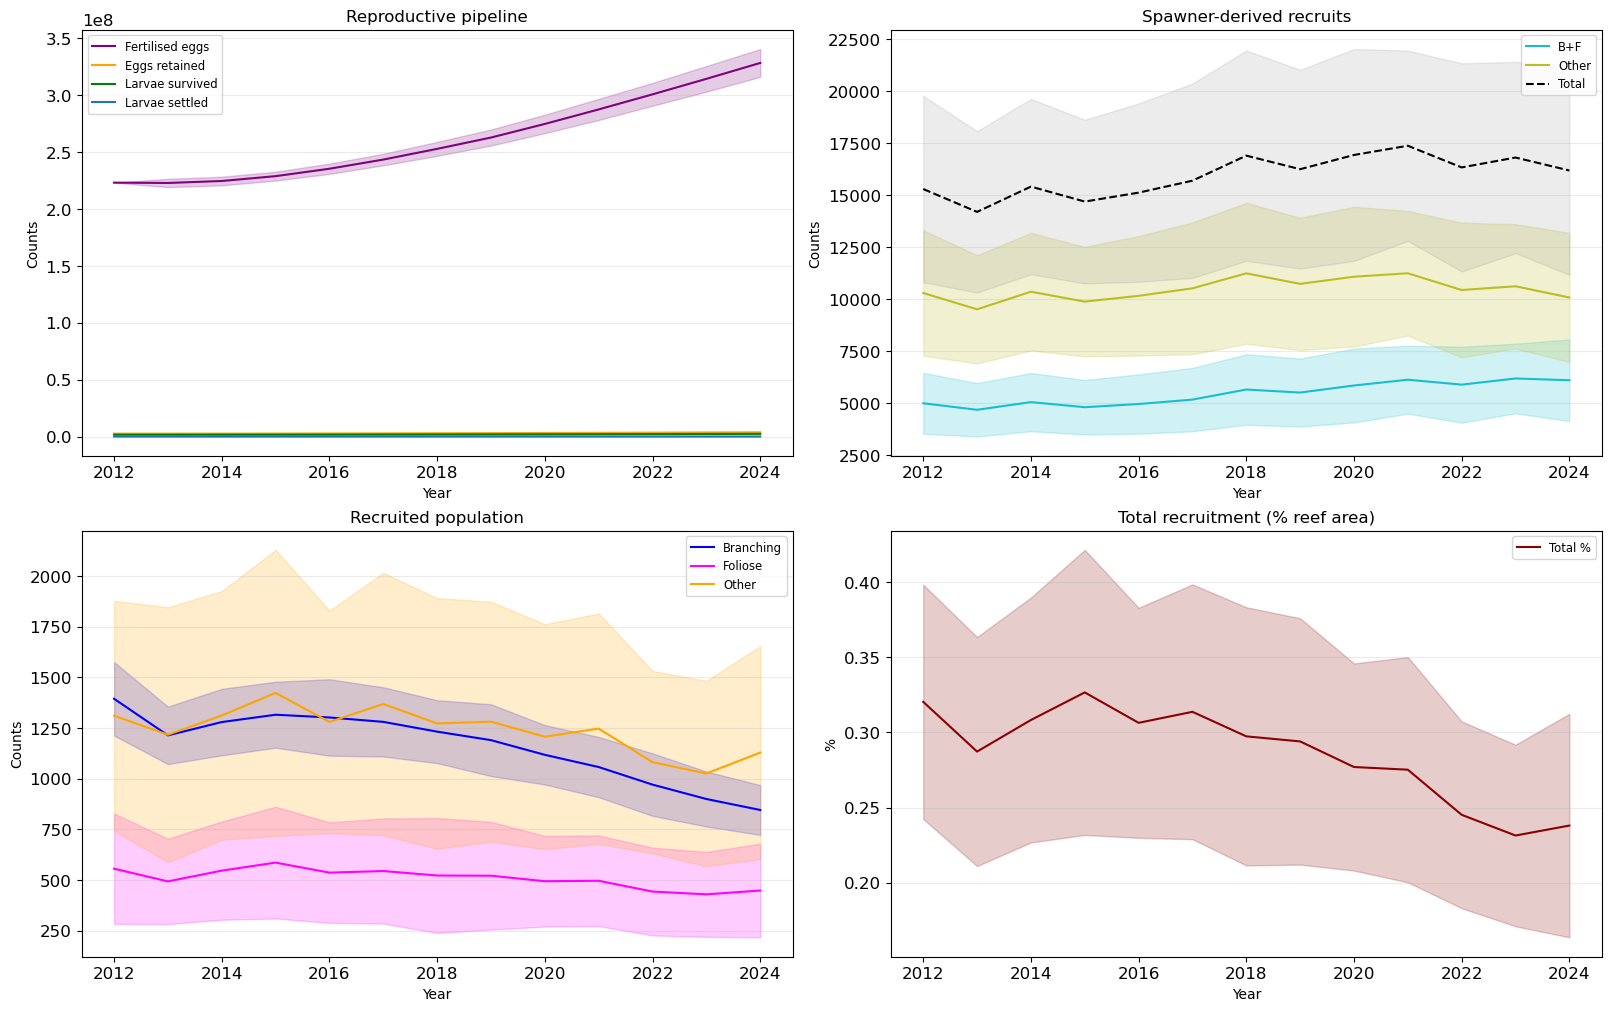

In [3]:
import os, numpy as np, matplotlib.pyplot as plt

n_iter = int(globals().get('number_of_iterations', 100))
ys = np.arange(int(year_start), int(year_end) + 1)
T  = len(ys)

metrics = {k: [] for k in [
    'fertilised_eggs_total', 'eggs_retained_total', 'larvae_survived_total',
    'larvae_settled_total', 'num_recruits_spawner_bf', 'num_recruits_spawner_ot',
    'num_recruits_spawner_total', 'recruited_branching_pop', 'recruited_foliose_pop',
    'recruited_other_pop', 'total_recruitment_perc']}

larval_surv_bf = globals().get('larval_survival_rate_branching_foliose',
                               0.84*0.87*0.93*0.94*0.95*0.96*0.965*0.97)
larval_surv_o  = globals().get('larval_survival_rate_other', 0.915**4)

for it in range(1, n_iter + 1):
    np.random.seed(42 + it); import random; random.seed(42 + it)
    set_current_run_id(it)
    run_coral_model(PSD_T0, MaxYear)

    fert=np.zeros(T); retained=np.zeros(T); survived=np.zeros(T); settled=np.zeros(T)
    spbf=np.zeros(T); spot=np.zeros(T); sptot=np.zeros(T)
    rec_b=np.zeros(T); rec_f=np.zeros(T); rec_o=np.zeros(T); rec_perc=np.zeros(T)

    for yy in range(T):
        try:
            row = opts.yearly_total_coral_cover_df.iloc[yy]
            coral_cover = {'Branching': float(row['Branching_Area (%)']),
                           'Foliose':   float(row['Foliose_Area (%)']),
                           'Other':     float(row['Other_Area (%)'])}
        except Exception:
            coral_cover = opts.current_coral_cover.copy()

        brooder_pct, spawner_bf_pct, spawner_o_pct = get_brooder_spawner_cover(coral_cover)

        try:
            avail_pct = float(opts.yearly_benthic_cover_df.loc[yy, 'available_substrate (%)'])
        except Exception:
            avail_pct = float(getattr(opts, 'available_substrate_percentage', 0.0))

        reef_m2 = float(opts.reef_area)

        try:
            spawn_month = get_spawn_month_for_run(it)
        except Exception:
            try:    spawn_month = get_spawn_month_current()
            except: spawn_month = int(getattr(opts, 'spawning_month'))

        suspended_in_month = 0.0
        if 'additional_sediment_exposure' in globals():
            suspended_in_month = float(additional_sediment_exposure.get((yy, spawn_month), (0.0,0.0))[0])

        spawner_cover_m2 = [max(0., spawner_bf_pct*reef_m2/100.), max(0., spawner_o_pct*reef_m2/100.)]
        eggs_decl  = float(eggs_decline_rate(getattr(opts,'dhw_lst',[0])[yy] if getattr(opts,'dhw_lst',None) else 0))
        eggs_dens  = getattr(opts, 'eggs_density', [egg_density_spawner_branching_foliose, egg_density_spawner_other])
        num_eggs   = [10000.*eggs_decl*(eggs_dens[i] if i<len(eggs_dens) else eggs_dens[-1])*spawner_cover_m2[i]
                      for i in range(2)]
        esr        = getattr(opts, 'eggs_spawning_rate', [1.]*2)
        col_decl   = colonies_spawning_decline_rate(getattr(opts,'dhw_lst',[0])[yy] if getattr(opts,'dhw_lst',None) else 0)
        eggs_sp    = [num_eggs[i]*(esr[i] if i<len(esr) else esr[-1])*col_decl for i in range(2)]

        efr = float(getattr(opts, 'eggs_fertilisation_rate', np.random.uniform(0.41,0.69)))
        if suspended_in_month > 0 and getattr(opts,'enable_sediment_exposure',True):
            coeff = globals().get('sedi_exp_fertilisation_coeff',{}).get('spawner',0.)
            susc  = float(globals().get('sediment_susceptibilityF',1.))
            efr  *= max(0., min(1., 1. + max(-1., min(0., coeff*suspended_in_month*susc))))

        fby    = [efr*e for e in eggs_sp];   ftot = float(np.sum(fby))
        rbf,ro = get_retention_rate()
        eby    = [fby[0]*rbf, fby[1]*ro];    etot = float(np.sum(eby))
        lby    = [eby[0]*larval_surv_bf, eby[1]*larval_surv_o]; ltot = float(np.sum(lby))
        sc     = get_settlement_rate(avail_pct)
        sby    = [sc*lby[0], sc*lby[1]];     stot = float(np.sum(sby))

        ssb = np.prod(spawner_branching_survival_rates) if 'spawner_branching_survival_rates' in globals() else np.prod([0.81,0.93,0.88,0.9])
        sso = np.prod(spawner_other_survival_rates)     if 'spawner_other_survival_rates'     in globals() else np.prod([0.865,0.83,0.91,0.925])
        nbf = sby[0]*ssb;  not_ = sby[1]*sso

        ba,fa,oa = get_recruited_corals(avail_pct, pop_flag=False)
        rb_ = get_population_number_from_surface_area(0, ba)
        rf_ = get_population_number_from_surface_area(0, fa)
        ro_ = get_population_number_from_surface_area(0, oa)
        rp  = 100.*(ba+fa+oa)/max(1., reef_m2)

        fert[yy]=ftot; retained[yy]=etot; survived[yy]=ltot; settled[yy]=stot
        spbf[yy]=nbf;  spot[yy]=not_;     sptot[yy]=nbf+not_
        rec_b[yy]=rb_; rec_f[yy]=rf_;     rec_o[yy]=ro_;  rec_perc[yy]=rp

    for k,v in zip(metrics.keys(),
                   [fert,retained,survived,settled,spbf,spot,sptot,rec_b,rec_f,rec_o,rec_perc]):
        metrics[k].append(v)

for k in metrics: metrics[k] = np.vstack(metrics[k]) if metrics[k] else np.zeros((0,T))
mu = {k: metrics[k].mean(axis=0) if metrics[k].size else np.zeros(T) for k in metrics}
sd = {k: metrics[k].std(axis=0)  if metrics[k].size else np.zeros(T) for k in metrics}

os.makedirs('output/figures', exist_ok=True)
fig, axs = plt.subplots(2, 2, figsize=(16,10), constrained_layout=True)

def _band(ax, y, s, color, label):
    ax.plot(ys, y, color=color, label=label)
    ax.fill_between(ys, np.maximum(0,y-s), y+s, color=color, alpha=0.2)

ax=axs[0,0]; _band(ax,mu['fertilised_eggs_total'],sd['fertilised_eggs_total'],'purple','Fertilised eggs')
_band(ax,mu['eggs_retained_total'],sd['eggs_retained_total'],'orange','Eggs retained')
_band(ax,mu['larvae_survived_total'],sd['larvae_survived_total'],'green','Larvae survived')
_band(ax,mu['larvae_settled_total'],sd['larvae_settled_total'],'tab:blue','Larvae settled')
ax.set_title('Reproductive pipeline'); ax.set_xlabel('Year'); ax.set_ylabel('Counts')
ax.legend(fontsize='small'); ax.grid(axis='y',alpha=0.25)

ax=axs[0,1]; _band(ax,mu['num_recruits_spawner_bf'],sd['num_recruits_spawner_bf'],'tab:cyan','B+F')
_band(ax,mu['num_recruits_spawner_ot'],sd['num_recruits_spawner_ot'],'tab:olive','Other')
ax.plot(ys,mu['num_recruits_spawner_total'],'k--',label='Total')
ax.fill_between(ys,np.maximum(0,mu['num_recruits_spawner_total']-sd['num_recruits_spawner_total']),
                mu['num_recruits_spawner_total']+sd['num_recruits_spawner_total'],color='grey',alpha=0.15)
ax.set_title('Spawner-derived recruits'); ax.set_xlabel('Year'); ax.set_ylabel('Counts')
ax.legend(fontsize='small'); ax.grid(axis='y',alpha=0.25)

ax=axs[1,0]; _band(ax,mu['recruited_branching_pop'],sd['recruited_branching_pop'],'blue','Branching')
_band(ax,mu['recruited_foliose_pop'],sd['recruited_foliose_pop'],'magenta','Foliose')
_band(ax,mu['recruited_other_pop'],sd['recruited_other_pop'],'orange','Other')
ax.set_title('Recruited population'); ax.set_xlabel('Year'); ax.set_ylabel('Counts')
ax.legend(fontsize='small'); ax.grid(axis='y',alpha=0.25)

ax=axs[1,1]; _band(ax,mu['total_recruitment_perc'],sd['total_recruitment_perc'],'darkred','Total %')
ax.set_title('Total recruitment (% reef area)'); ax.set_xlabel('Year'); ax.set_ylabel('%')
ax.legend(fontsize='small'); ax.grid(axis='y',alpha=0.25)

outpath=f"output/figures/{globals().get('title','run')}_recruitment_summary_{n_iter}iter.png"
fig.savefig(outpath, dpi=200, bbox_inches='tight')
print("Saved:", outpath); plt.show()

Growth stress entries : 36
PCM stress entries    : 36
Sediment spike years  : []
Total coral available : True
Recruitment available : True
OK Growth stress plotted
OK PCM stress plotted
X  No sediment spikes detected
OK Coral cover plotted
OK Recruitment plotted

Saved: output/figures/run_recovery_lag_diagnostics.png


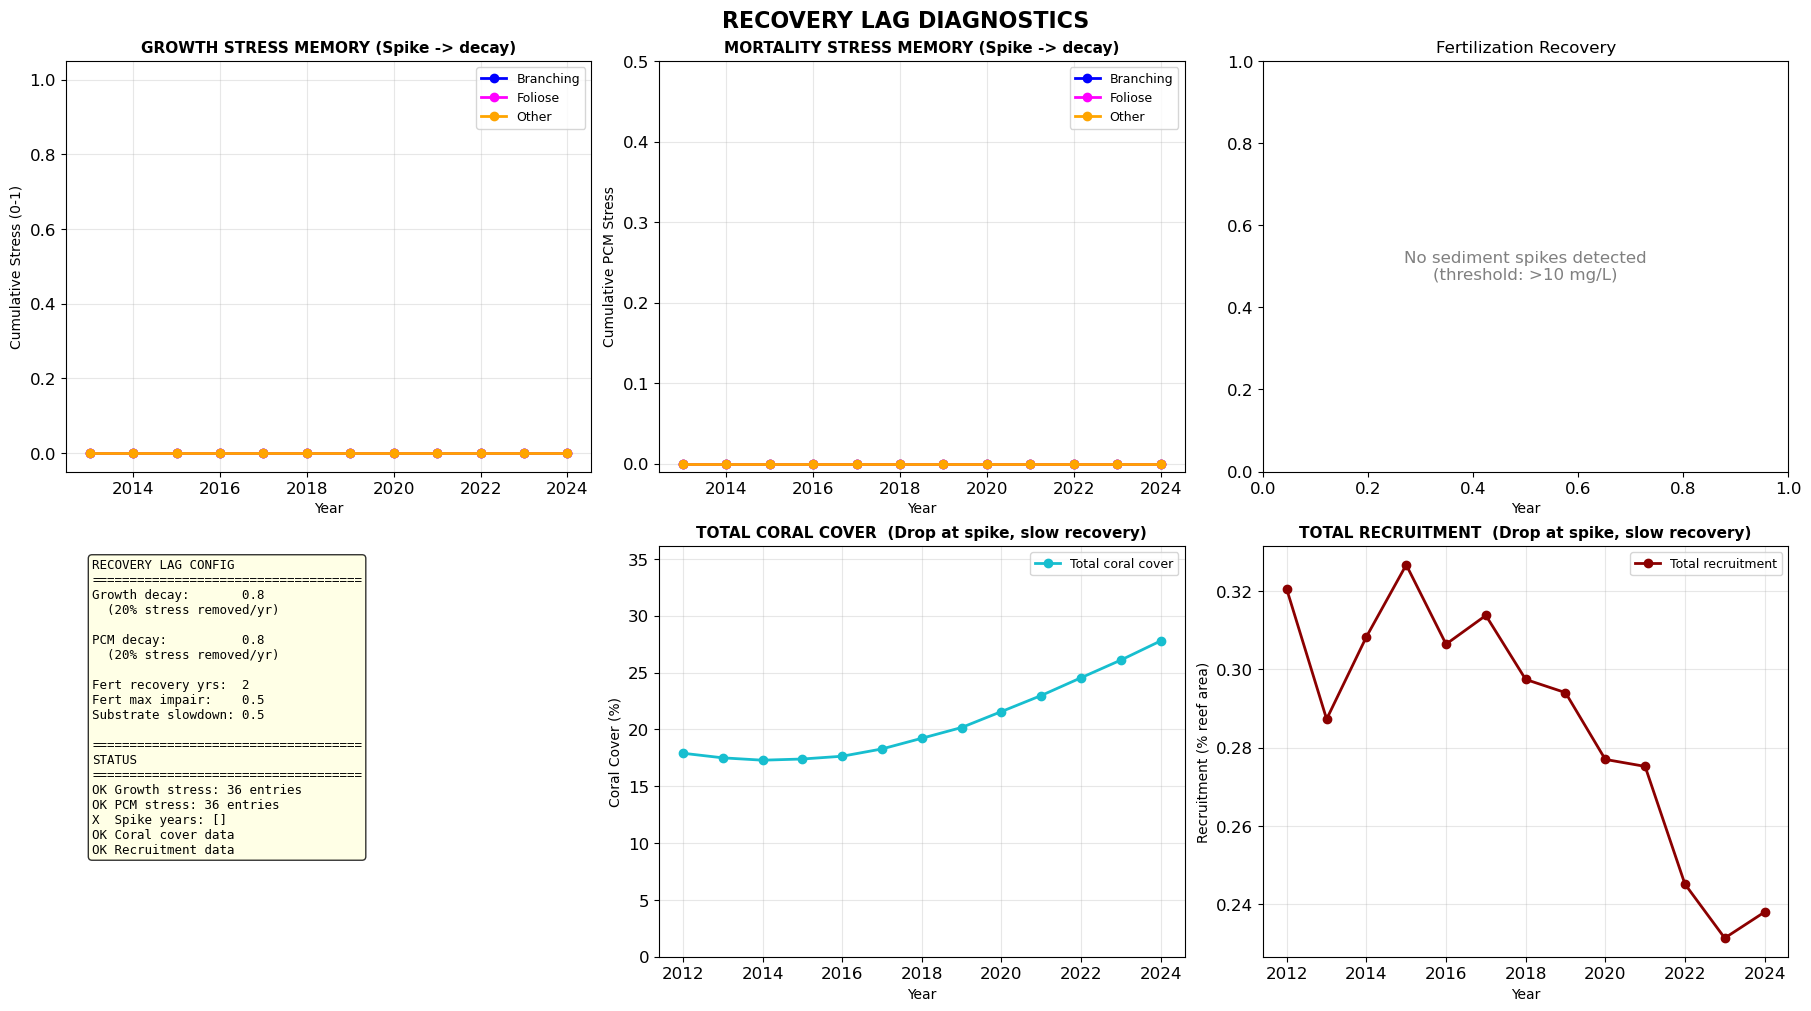

In [4]:
import os, numpy as np, matplotlib.pyplot as plt

g        = globals()
opts_obj = g.get('opts', None)

year_start = int(g.get('year_start', 2011))
year_end   = int(g.get('year_end', year_start + 10))
x = np.arange(year_start, year_end + 1)
T = len(x)

# ── Collect all data up front ────────────────────────────────────────────────

# Stress memory: saved to opts at end of run_yearly_change, globals as fallback
growth_stress = (getattr(g.get('opts', None), 'growth_stress_memory', None) or g.get('growth_stress_memory', {}))
pcm_stress    = (getattr(g.get('opts', None), 'pcm_stress_memory',    None) or g.get('pcm_stress_memory',    {}))

# Sediment spikes from sedi_years (does NOT rely on last_sediment_event_year global)
sedi_years_dict      = g.get('sedi_years', {})
sediment_spike_years = sorted({
    year_start + ry
    for (ry, mo), (susp, dep) in sedi_years_dict.items()
    if susp is not None and susp > 10
})
first_spike_rel = (sediment_spike_years[0] - year_start) if sediment_spike_years else None

fert_recovery_years = g.get('fert_recovery_years', 2)
fert_max_impairment = g.get('fert_recovery_max_impairment', 0.3)

# Total coral cover: opts first, then b+f+o from globals
total_coral = None
if opts_obj is not None and hasattr(opts_obj, 'yearly_total_coral_cover_df'):
    _df = opts_obj.yearly_total_coral_cover_df
    if 'total_coral_cover (%)' in _df.columns:
        v = _df['total_coral_cover (%)'].values
        total_coral = v[:T] if len(v) >= T else np.pad(v, (0, T - len(v)), constant_values=np.nan)
if total_coral is None or np.all(np.isnan(total_coral)):
    _b = g.get('b_mean'); _f = g.get('f_mean'); _o = g.get('o_mean')
    if _b is not None and _f is not None and _o is not None:
        total_coral = np.asarray(_b)[:T] + np.asarray(_f)[:T] + np.asarray(_o)[:T]

# Recruitment from mu dict (set by recruitment metrics cell)
mu = g.get('mu', {})
_tr = mu.get('total_recruitment_perc')
total_recruit = np.asarray(_tr, dtype=float)[:T] if (_tr is not None and len(_tr) >= T) else None

# ── Print summary ─────────────────────────────────────────────────────────────
print("=" * 60)
print(f"Growth stress entries : {len(growth_stress)}")
print(f"PCM stress entries    : {len(pcm_stress)}")
print(f"Sediment spike years  : {sediment_spike_years}")
print(f"Total coral available : {total_coral is not None and not np.all(np.isnan(total_coral))}")
print(f"Recruitment available : {total_recruit is not None}")
print("=" * 60)

# ── Helpers ──────────────────────────────────────────────────────────────────
COLORS = {'Branching': 'blue', 'Foliose': 'fuchsia', 'Other': 'orange'}

def mark_spikes(ax):
    for yr in sediment_spike_years:
        ax.axvline(yr, color='red', linestyle='--', alpha=0.4, linewidth=1.5)

def plot_stress(ax, stress_dict, title, ylabel, ylim):
    data = {'Branching': {}, 'Foliose': {}, 'Other': {}}
    for (ct, yr), stress in stress_dict.items():
        if ct in data:
            data[ct][year_start + yr] = stress
    for ct, col in COLORS.items():
        if data[ct]:
            yrs = sorted(data[ct])
            ax.plot(yrs, [data[ct][y] for y in yrs], '-o', color=col,
                    label=ct, linewidth=2, markersize=6)
    mark_spikes(ax)
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_ylabel(ylabel)
    ax.set_ylim(*ylim)
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=9)

# ── Figure ───────────────────────────────────────────────────────────────────
fig, axs = plt.subplots(2, 3, figsize=(18, 10), constrained_layout=True)

# Panel 0,0: GROWTH STRESS
ax = axs[0, 0]
if growth_stress:
    plot_stress(ax, growth_stress,
                'GROWTH STRESS MEMORY (Spike -> decay)',
                'Cumulative Stress (0-1)', (-0.05, 1.05))
    print("OK Growth stress plotted")
else:
    ax.text(0.5, 0.5, 'NO GROWTH STRESS DATA\n\nHas utils.py been updated\nand model re-run?',
            ha='center', va='center', transform=ax.transAxes,
            fontsize=12, color='red', weight='bold')
    ax.set_title('Growth Stress Memory')
    print("X  No growth stress data")
ax.set_xlabel('Year')

# Panel 0,1: PCM STRESS
ax = axs[0, 1]
if pcm_stress:
    ymax = max(0.5, max(pcm_stress.values()) * 1.2)
    plot_stress(ax, pcm_stress,
                'MORTALITY STRESS MEMORY (Spike -> decay)',
                'Cumulative PCM Stress', (-0.01, ymax))
    print("OK PCM stress plotted")
else:
    ax.text(0.5, 0.5, 'NO PCM STRESS DATA\n\nHas utils.py been updated\nand model re-run?',
            ha='center', va='center', transform=ax.transAxes,
            fontsize=12, color='red', weight='bold')
    ax.set_title('Mortality Stress Memory')
    print("X  No PCM stress data")
ax.set_xlabel('Year')

# Panel 0,2: FERTILIZATION RECOVERY
ax = axs[0, 2]
if first_spike_rel is not None:
    yrs_p, imp_p = [], []
    for yr in range(T):
        ys_ = yr - first_spike_rel
        if ys_ >= 0:
            imp = fert_max_impairment * max(0., 1. - min(1., ys_ / fert_recovery_years)) \
                  if ys_ <= fert_recovery_years else 0.
            yrs_p.append(year_start + yr)
            imp_p.append(imp)
    ax.plot(yrs_p, imp_p, '-o', color='purple', linewidth=3, markersize=8, label='Fert. impairment')
    ax.axhline(0, color='gray', linewidth=1, alpha=0.5)
    mark_spikes(ax)
    ax.set_title(
        f'FERTILIZATION RECOVERY  (Spike: {sediment_spike_years[0]}, {fert_recovery_years}yr)',
        fontsize=11, fontweight='bold')
    ax.set_ylabel('Fertilization Impairment (0-1)')
    ax.set_ylim(-0.05, fert_max_impairment * 1.2)
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=9)
    print("OK Fertilization recovery plotted")
else:
    ax.text(0.5, 0.5, 'No sediment spikes detected\n(threshold: >10 mg/L)',
            ha='center', va='center', transform=ax.transAxes, fontsize=12, color='gray')
    ax.set_title('Fertilization Recovery')
    print("X  No sediment spikes detected")
ax.set_xlabel('Year')

# Panel 1,0: CONFIG SUMMARY
ax = axs[1, 0]
ax.axis('off')
lines = [
    "RECOVERY LAG CONFIG", "=" * 36,
    f"Growth decay:       {g.get('growth_recovery_decay', 'NOT SET')}",
    f"  ({(1 - g.get('growth_recovery_decay', 0)) * 100:.0f}% stress removed/yr)", "",
    f"PCM decay:          {g.get('pcm_recovery_decay', 'NOT SET')}",
    f"  ({(1 - g.get('pcm_recovery_decay', 0)) * 100:.0f}% stress removed/yr)", "",
    f"Fert recovery yrs:  {fert_recovery_years}",
    f"Fert max impair:    {fert_max_impairment}",
    f"Substrate slowdown: {g.get('substrate_recovery_slowdown', 'NOT SET')}", "",
    "=" * 36, "STATUS", "=" * 36,
    f"{'OK' if growth_stress else 'X '} Growth stress: {len(growth_stress)} entries",
    f"{'OK' if pcm_stress    else 'X '} PCM stress: {len(pcm_stress)} entries",
    f"{'OK' if sediment_spike_years else 'X '} Spike years: {sediment_spike_years}",
    f"{'OK' if total_coral is not None else 'X '} Coral cover data",
    f"{'OK' if total_recruit is not None else 'X '} Recruitment data",
]
ax.text(0.05, 0.97, "\n".join(lines), transform=ax.transAxes,
        fontsize=9, va='top', family='monospace',
        bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

# Panel 1,1: TOTAL CORAL COVER
ax = axs[1, 1]
if total_coral is not None and not np.all(np.isnan(total_coral)):
    ax.plot(x, total_coral, '-o', color='tab:cyan', linewidth=2, markersize=6, label='Total coral cover')
    mark_spikes(ax)
    ax.set_title('TOTAL CORAL COVER  (Drop at spike, slow recovery)', fontsize=11, fontweight='bold')
    ax.set_ylabel('Coral Cover (%)')
    ax.set_ylim(0, min(100, np.nanmax(total_coral) * 1.3))
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=9)
    print("OK Coral cover plotted")
else:
    ax.text(0.5, 0.5, 'Coral cover not available',
            ha='center', va='center', transform=ax.transAxes, fontsize=12, color='gray')
    ax.set_title('Total Coral Cover')
    print("X  No coral cover data")
ax.set_xlabel('Year')

# Panel 1,2: RECRUITMENT
ax = axs[1, 2]
if total_recruit is not None:
    ax.plot(x, total_recruit, '-o', color='darkred', linewidth=2, markersize=6, label='Total recruitment')
    mark_spikes(ax)
    ax.set_title('TOTAL RECRUITMENT  (Drop at spike, slow recovery)', fontsize=11, fontweight='bold')
    ax.set_ylabel('Recruitment (% reef area)')
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=9)
    print("OK Recruitment plotted")
else:
    ax.text(0.5, 0.5, 'Recruitment data not available',
            ha='center', va='center', transform=ax.transAxes, fontsize=12, color='gray')
    ax.set_title('Total Recruitment')
    print("X  No recruitment data")
ax.set_xlabel('Year')

# ── Save ─────────────────────────────────────────────────────────────────────
fig.suptitle('RECOVERY LAG DIAGNOSTICS', fontsize=16, fontweight='bold')
os.makedirs('output/figures', exist_ok=True)
outfn = f"output/figures/{g.get('title', 'run')}_recovery_lag_diagnostics.png"
fig.savefig(outfn, dpi=200, bbox_inches='tight')
print(f"\nSaved: {outfn}")
plt.show()

RECOVERY LAG DIAGNOSTICS

Spike years detected: []
Growth stress entries: 36
PCM stress entries: 36

✓ Saved: output/figures/run_recovery_lag_final.png



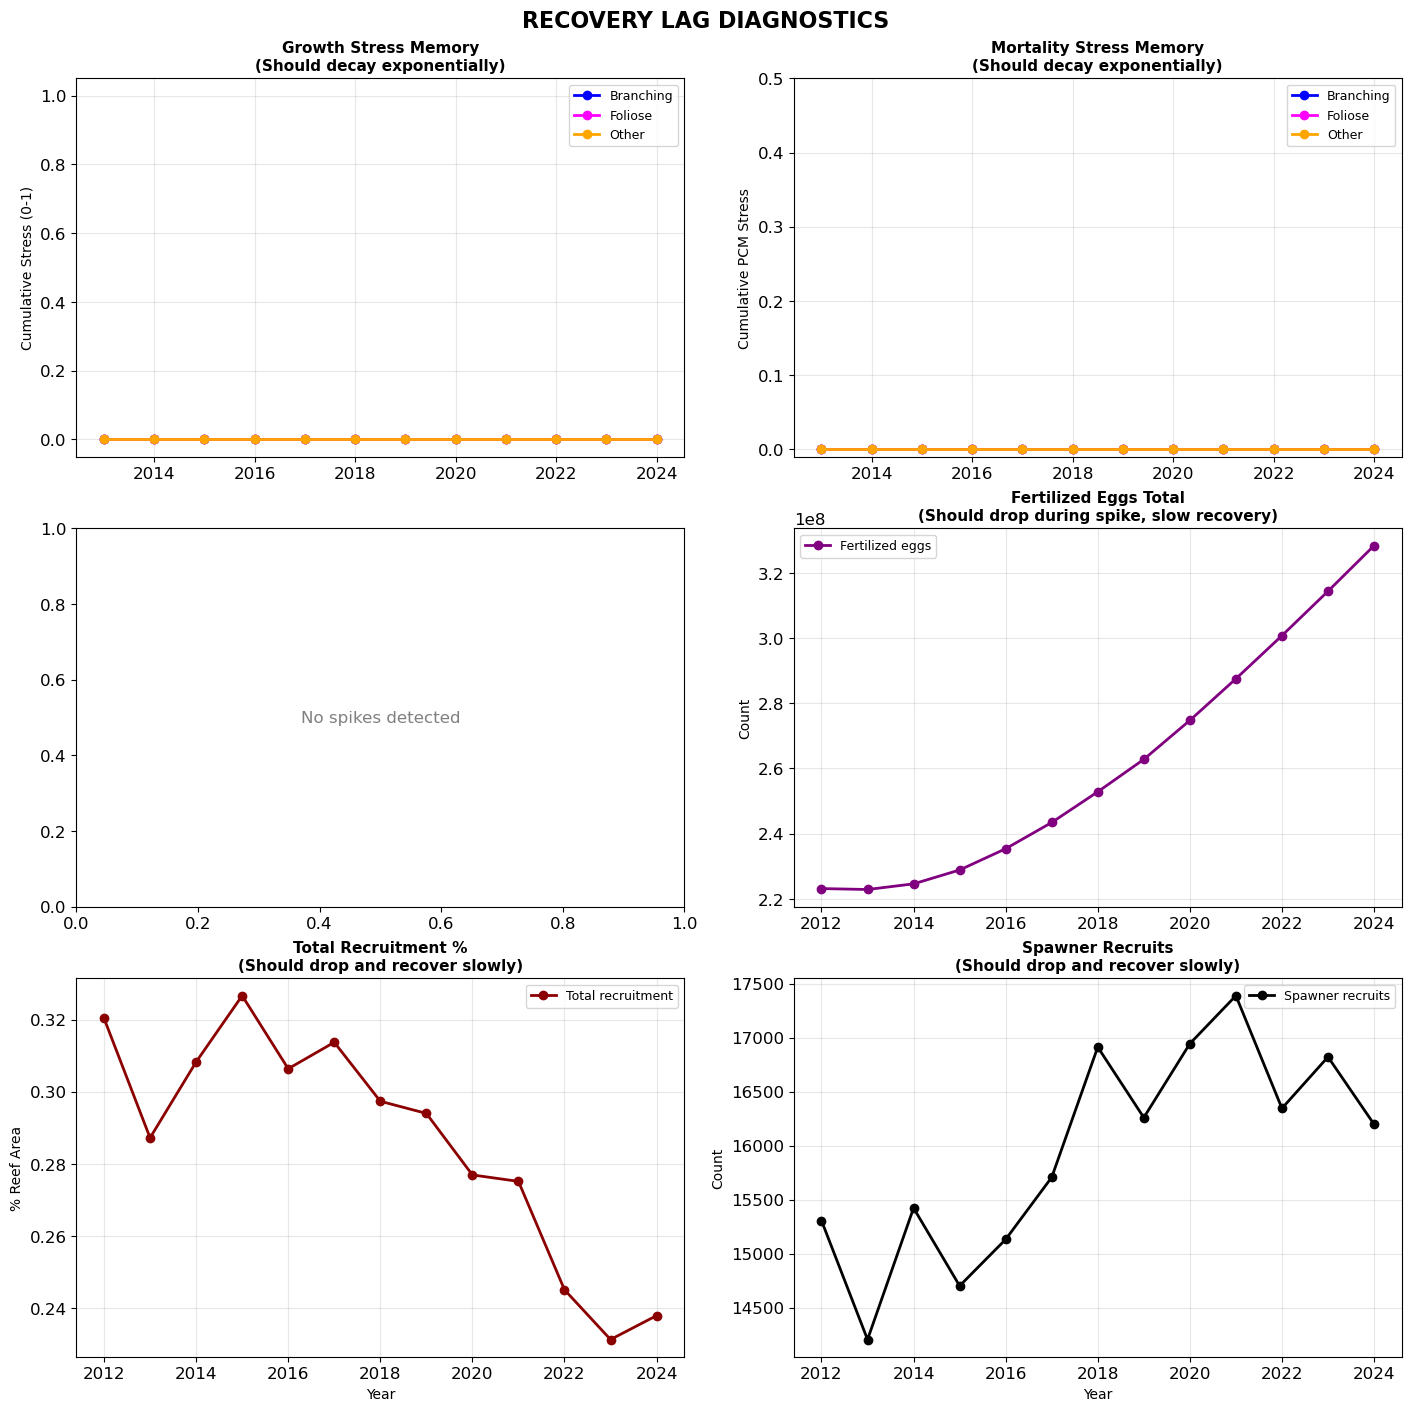

SUMMARY
Sediment spikes: []
Growth stress tracked: 36 entries
PCM stress tracked: 36 entries
Recovery config:
  - Growth decay: 0.8
  - PCM decay: 0.8
  - Fert recovery years: 2
  - Fert max impairment: 0.5


In [5]:
# RECOVERY LAG DIAGNOSTICS - USING ACTUAL AVAILABLE DATA
import os
import numpy as np
import matplotlib.pyplot as plt

g = globals()

year_start = int(g.get('year_start', 2011))
year_end = int(g.get('year_end', year_start + 10))
x = np.arange(year_start, year_end + 1)
T = len(x)

print("=" * 70)
print("RECOVERY LAG DIAGNOSTICS")
print("=" * 70)

# Get mu/sd dictionaries (from your recruitment metrics cell)
mu = g.get('mu', {})
sd = g.get('sd', {})

# Find sediment spikes
sedi_years_dict = g.get('sedi_years', {})
sediment_spike_years = []
max_suspended = 0

if sedi_years_dict:
    for (rel_year, month), (susp, dep) in sedi_years_dict.items():
        if susp is not None:
            max_suspended = max(max_suspended, susp)
            if susp > 10:
                actual_year = year_start + rel_year
                if actual_year not in sediment_spike_years:
                    sediment_spike_years.append(actual_year)
                    print(f"Sediment spike: Year {actual_year}, Month {month}, Suspended={susp:.1f} mg/L")

print(f"\nSpike years detected: {sediment_spike_years}")

# Get stress memory
growth_stress = (getattr(g.get('opts', None), 'growth_stress_memory', None) or g.get('growth_stress_memory', {}))
pcm_stress    = (getattr(g.get('opts', None), 'pcm_stress_memory',    None) or g.get('pcm_stress_memory',    {}))

print(f"Growth stress entries: {len(growth_stress)}")
print(f"PCM stress entries: {len(pcm_stress)}")

# ==============================================================================
# PLOTTING
# ==============================================================================
fig, axs = plt.subplots(3, 2, figsize=(14, 14), constrained_layout=True)

# ------------------------------------------------------------------------------
# Panel 0,0: GROWTH STRESS
# ------------------------------------------------------------------------------
ax = axs[0, 0]
if growth_stress:
    data = {'Branching': {}, 'Foliose': {}, 'Other': {}}
    for (coral_type, year), stress in growth_stress.items():
        if coral_type in data:
            data[coral_type][year_start + year] = stress
    
    colors = {'Branching': 'blue', 'Foliose': 'fuchsia', 'Other': 'orange'}
    for coral_type, color in colors.items():
        if data[coral_type]:
            years = sorted(data[coral_type].keys())
            stress = [data[coral_type][y] for y in years]
            ax.plot(years, stress, '-o', color=color, label=coral_type, linewidth=2, markersize=6)
    
    for spike_year in sediment_spike_years:
        ax.axvline(spike_year, color='red', linestyle='--', alpha=0.5, linewidth=2)
    
    ax.set_title('Growth Stress Memory\n(Should decay exponentially)', fontsize=11, fontweight='bold')
    ax.set_ylabel('Cumulative Stress (0-1)')
    ax.set_ylim(-0.05, 1.05)
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=9)
else:
    ax.text(0.5, 0.5, 'NO DATA', ha='center', va='center', transform=ax.transAxes, fontsize=14, color='red')

# ------------------------------------------------------------------------------
# Panel 0,1: PCM STRESS
# ------------------------------------------------------------------------------
ax = axs[0, 1]
if pcm_stress:
    data = {'Branching': {}, 'Foliose': {}, 'Other': {}}
    for (coral_type, year), stress in pcm_stress.items():
        if coral_type in data:
            data[coral_type][year_start + year] = stress
    
    colors = {'Branching': 'blue', 'Foliose': 'fuchsia', 'Other': 'orange'}
    for coral_type, color in colors.items():
        if data[coral_type]:
            years = sorted(data[coral_type].keys())
            stress = [data[coral_type][y] for y in years]
            ax.plot(years, stress, '-o', color=color, label=coral_type, linewidth=2, markersize=6)
    
    for spike_year in sediment_spike_years:
        ax.axvline(spike_year, color='red', linestyle='--', alpha=0.5, linewidth=2)
    
    ax.set_title('Mortality Stress Memory\n(Should decay exponentially)', fontsize=11, fontweight='bold')
    ax.set_ylabel('Cumulative PCM Stress')
    ax.set_ylim(-0.01, max(0.5, max(pcm_stress.values()) * 1.2) if pcm_stress else 0.5)
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=9)
else:
    ax.text(0.5, 0.5, 'NO DATA', ha='center', va='center', transform=ax.transAxes, fontsize=14, color='red')

# ------------------------------------------------------------------------------
# Panel 1,0: FERTILIZATION RECOVERY
# ------------------------------------------------------------------------------
ax = axs[1, 0]
if sediment_spike_years:
    first_spike = min(sediment_spike_years)
    last_event = first_spike - year_start
    recovery_years = g.get('fert_recovery_years', 2)
    max_impairment = g.get('fert_recovery_max_impairment', 0.3)
    
    years = []
    impairment = []
    
    for year in range(T):
        years_since = year - last_event
        if years_since >= 0:
            if years_since <= recovery_years:
                recovery_progress = min(1.0, years_since / recovery_years)
                imp = max_impairment * (1.0 - recovery_progress)
            else:
                imp = 0.0
            years.append(year_start + year)
            impairment.append(imp)
    
    ax.plot(years, impairment, '-o', color='purple', linewidth=3, markersize=8, label='Fert impairment')
    ax.axvline(first_spike, color='red', linestyle='--', linewidth=2, alpha=0.7, label='Spike')
    ax.axhline(0, color='gray', linestyle='-', linewidth=1, alpha=0.5)
    
    ax.set_title(f'Fertilization Recovery\n(Spike: {first_spike}, Recovery: {recovery_years}yr)', 
                 fontsize=11, fontweight='bold')
    ax.set_ylabel('Fertilization Impairment (0-1)')
    ax.set_ylim(-0.05, max_impairment * 1.2)
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=9)
else:
    ax.text(0.5, 0.5, 'No spikes detected', ha='center', va='center', 
            transform=ax.transAxes, fontsize=12, color='gray')

# ------------------------------------------------------------------------------
# Panel 1,1: FERTILIZED EGGS (from mu)
# ------------------------------------------------------------------------------
ax = axs[1, 1]
fert = mu.get('fertilised_eggs_total', None)
if fert is not None:
    fert = np.asarray(fert, dtype=float)
    if fert.size >= T:
        ax.plot(x, fert[:T], '-o', color='purple', linewidth=2, markersize=6, label='Fertilized eggs')
        
        for spike_year in sediment_spike_years:
            ax.axvline(spike_year, color='red', linestyle='--', alpha=0.3, linewidth=1)
        
        ax.set_title('Fertilized Eggs Total\n(Should drop during spike, slow recovery)', fontsize=11, fontweight='bold')
        ax.set_ylabel('Count')
        ax.grid(True, alpha=0.3)
        ax.legend(fontsize=9)
    else:
        ax.text(0.5, 0.5, f'Size mismatch: {fert.size} vs {T}', ha='center', va='center', 
                transform=ax.transAxes, fontsize=12)
else:
    ax.text(0.5, 0.5, 'Data not available', ha='center', va='center', 
            transform=ax.transAxes, fontsize=12)

# ------------------------------------------------------------------------------
# Panel 2,0: RECRUITMENT % (from mu)
# ------------------------------------------------------------------------------
ax = axs[2, 0]
recruit_pct = mu.get('total_recruitment_perc', None)
if recruit_pct is not None:
    recruit_pct = np.asarray(recruit_pct, dtype=float)
    if recruit_pct.size >= T:
        ax.plot(x, recruit_pct[:T], '-o', color='darkred', linewidth=2, markersize=6, label='Total recruitment')
        
        for spike_year in sediment_spike_years:
            ax.axvline(spike_year, color='red', linestyle='--', alpha=0.3, linewidth=1)
        
        ax.set_title('Total Recruitment %\n(Should drop and recover slowly)', fontsize=11, fontweight='bold')
        ax.set_xlabel('Year')
        ax.set_ylabel('% Reef Area')
        ax.grid(True, alpha=0.3)
        ax.legend(fontsize=9)
        
        # DIAGNOSTIC: Check if recruitment is actually affected
        if sediment_spike_years:
            spike_idx = sediment_spike_years[0] - year_start
            if 0 <= spike_idx < T:
                pre_spike = recruit_pct[max(0, spike_idx-1)]
                at_spike = recruit_pct[spike_idx]
                post_spike = recruit_pct[min(T-1, spike_idx+1)] if spike_idx+1 < T else at_spike
                
                print(f"\nRECRUITMENT CHECK:")
                print(f"  Pre-spike (yr {sediment_spike_years[0]-1}): {pre_spike:.4f}%")
                print(f"  At spike (yr {sediment_spike_years[0]}): {at_spike:.4f}%")
                print(f"  Post-spike (yr {sediment_spike_years[0]+1}): {post_spike:.4f}%")
                
                if at_spike > pre_spike:
                    print(f"  ⚠️  WARNING: Recruitment INCREASED during spike!")
                else:
                    print(f"  ✓ Recruitment dropped by {(pre_spike - at_spike)/pre_spike * 100:.1f}%")
    else:
        ax.text(0.5, 0.5, f'Size mismatch', ha='center', va='center', transform=ax.transAxes, fontsize=12)
else:
    ax.text(0.5, 0.5, 'Data not available', ha='center', va='center', transform=ax.transAxes, fontsize=12)

# ------------------------------------------------------------------------------
# Panel 2,1: SPAWNER RECRUITS (from mu)
# ------------------------------------------------------------------------------
ax = axs[2, 1]
spawner_tot = mu.get('num_recruits_spawner_total', None)
if spawner_tot is not None:
    spawner_tot = np.asarray(spawner_tot, dtype=float)
    if spawner_tot.size >= T:
        ax.plot(x, spawner_tot[:T], '-o', color='black', linewidth=2, markersize=6, label='Spawner recruits')
        
        for spike_year in sediment_spike_years:
            ax.axvline(spike_year, color='red', linestyle='--', alpha=0.3, linewidth=1)
        
        ax.set_title('Spawner Recruits\n(Should drop and recover slowly)', fontsize=11, fontweight='bold')
        ax.set_xlabel('Year')
        ax.set_ylabel('Count')
        ax.grid(True, alpha=0.3)
        ax.legend(fontsize=9)
    else:
        ax.text(0.5, 0.5, f'Size mismatch', ha='center', va='center', transform=ax.transAxes, fontsize=12)
else:
    ax.text(0.5, 0.5, 'Data not available', ha='center', va='center', transform=ax.transAxes, fontsize=12)

# ==============================================================================
# SAVE
# ==============================================================================
fig.suptitle('RECOVERY LAG DIAGNOSTICS', fontsize=16, fontweight='bold')
os.makedirs('output/figures', exist_ok=True)
outfn = f"output/figures/{g.get('title', 'run')}_recovery_lag_final.png"
fig.savefig(outfn, dpi=200, bbox_inches='tight')
print(f"\n✓ Saved: {outfn}\n")
plt.show()

print("=" * 70)
print("SUMMARY")
print("=" * 70)
print(f"Sediment spikes: {sediment_spike_years}")
print(f"Growth stress tracked: {len(growth_stress)} entries")
print(f"PCM stress tracked: {len(pcm_stress)} entries")
print(f"Recovery config:")
print(f"  - Growth decay: {g.get('growth_recovery_decay', 'NOT SET')}")
print(f"  - PCM decay: {g.get('pcm_recovery_decay', 'NOT SET')}")
print(f"  - Fert recovery years: {g.get('fert_recovery_years', 'NOT SET')}")
print(f"  - Fert max impairment: {g.get('fert_recovery_max_impairment', 'NOT SET')}")
print("=" * 70)